In [1]:
import os
os.environ['PYSLICE_BACKEND'] = 'torch'
os.environ['PYSLICE_DEVICE'] = 'cpu'

In [2]:
"""
TEM Diffraction: Structure → Potential → Diffraction Pattern
=============================================================

The simplest multislice workflow: illuminate a structure with a parallel
electron beam and compute the diffraction pattern.

Along the way we visualize:
  1. The atomic structure (projected along the beam direction)
  2. The resulting electron diffraction pattern
  3. (Optional) The projected electrostatic potential — for diagnostic purposes

No external input files are needed — the structure is created from scratch.
"""

import os
import numpy as np
import matplotlib.pyplot as plt
from ase import Atoms
from pyslice import Loader, MultisliceCalculator, Potential

print('loaded')

os.makedirs("outputs", exist_ok=True)

# ---------------------------------------------------------------------------
# 1. Build an hBN monolayer with ASE
# ---------------------------------------------------------------------------
# Orthorhombic unit cell (4 atoms) derived from the hexagonal lattice.
# This ensures a perfectly periodic orthogonal box for multislice.
a = 2.504      # hBN lattice parameter (Å)
b = a * np.sqrt(3)
c = 3.392      # z spacing (vacuum)

unit_cell = Atoms(
    symbols=["B", "N", "B", "N"],
    positions=[
        [0.0,   b / 3,     c / 2],
        [a / 2, b / 6,     c / 2],
        [a / 2, 5 * b / 6, c / 2],
        [0.0,   2 * b / 3, c / 2],
    ],
    cell=[a, b, c],
    pbc=True,
)
reps = (20, 10, 5)
atoms = unit_cell * reps  # 4000 atoms, ~50 × 43 × 17 Å (5 layers)
print(f"Created hBN supercell: {len(atoms)} atoms, "
      f"box = {atoms.cell[0,0]:.1f} × {atoms.cell[1,1]:.1f} Å")

# Load into PySlice and add frozen-phonon displacements
trajectory = Loader(atoms=atoms).load()
trajectory = trajectory.generate_random_displacements(
    n_displacements=10, sigma=0.05, seed=0,
)

# ---------------------------------------------------------------------------
# 2. Plot the atomic structure (xy projection, first layer only)
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(5, 5))
colors = {"B": "#1f77b4", "N": "#ff7f0e"}
for atom_type in np.unique(trajectory.atom_types):
    mask = trajectory.atom_types == atom_type
    pos = trajectory.positions[0, mask]
    # Show only the first layer to avoid overlapping markers
    z_mid = pos[:, 2].min() + 0.5
    layer_mask = pos[:, 2] < z_mid
    pos = pos[layer_mask]
    label = str(atom_type)
    ax.scatter(pos[:, 0], pos[:, 1], c=colors.get(label, "gray"),
               s=60, label=label, edgecolors="k", linewidths=0.5)
ax.set_xlabel("x (Å)")
ax.set_ylabel("y (Å)")
ax.set_aspect("equal")
ax.legend()
ax.set_title("hBN monolayer (xy projection)")
fig.tight_layout()
fig.savefig("outputs/tem_structure.png", dpi=150)
plt.close(fig)
print("Saved structure plot")

# ---------------------------------------------------------------------------
# 3. Set up parallel-beam multislice
# ---------------------------------------------------------------------------
calc = MultisliceCalculator()
calc.setup(
    trajectory,
    aperture=0,        # Parallel beam (plane wave)
    voltage_eV=100e3,
    sampling=0.05,
    slice_thickness=0.5,
    cache_levels=[],
)

# ---------------------------------------------------------------------------
# 4. Run multislice and plot the diffraction pattern
# ---------------------------------------------------------------------------
# MultisliceCalculator builds the potential internally — you do NOT need to
# construct a Potential object yourself.  We do it below purely to visualize
# what the electrons scatter from.
wf = calc.run()
wf.plot_reciprocal(
    "outputs/tem_diffraction.png",
#    nuke_zerobeam=True,
    powerscaling=0.05,
    extent=[-2, 2, -2, 2],
)
plt.close()
print("Saved diffraction pattern")

# ---------------------------------------------------------------------------
# 5. (Optional) Visualize the projected potential
# ---------------------------------------------------------------------------
# This is NOT part of the normal workflow — just a diagnostic visualization.
# The Potential class lets you inspect the electrostatic potential that the
# multislice algorithm scatters electrons from.
potential_pyslice = Potential(
    calc.xs, calc.ys, calc.zs,
    trajectory.positions[0], list(trajectory.atom_types),
    kind="kirkland", device=calc.device, slice_axis=calc.slice_axis,
)
potential_pyslice.build()
potential_pyslice.plot(filename="outputs/tem_potential.png")
plt.close()
print("Saved projected potential (optional diagnostic)")

cpu <class 'numpy.float64'> <class 'numpy.complex128'>
failed to import pySEA: No module named 'pySEA'
loaded
Created hBN supercell: 4000 atoms, box = 50.1 × 43.4 Å
Saved structure plot


Processing frames: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:25<00:00,  2.55s/frame]


Saved diffraction pattern
Saved projected potential (optional diagnostic)


(-50.0, 50.0)

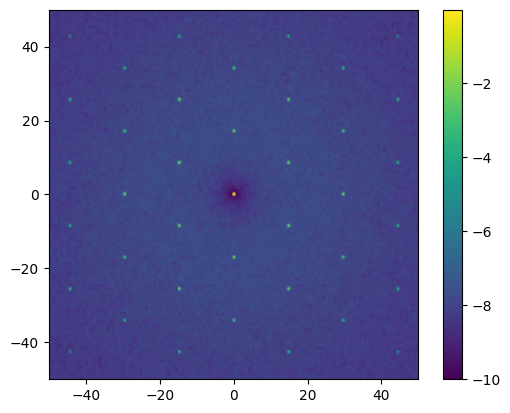

In [3]:
from numpy.fft import fftshift

fig, ax = plt.subplots()

wavs_pyslice = wf.array
if type(wavs_pyslice) != np.ndarray:
    wavs_pyslice = wavs_pyslice.numpy()
wavs_pyslice = np.copy(wavs_pyslice)
wavs_pyslice /= np.sqrt((np.abs(wavs_pyslice)**2).sum(axis=(-2,-3), keepdims=True))

wavelength = wf.probe.wavelength
if hasattr(wavelength, 'cpu'):
    wavelength = wavelength.numpy()

thetax = fftshift(wf.probe.kxs) * wavelength * 1e3
thetay = fftshift(wf.probe.kys) * wavelength * 1e3

extent = (thetax[0], thetax[-1], thetay[0], thetay[-1])

intensity = (np.abs(wavs_pyslice[0,...,0])**2).mean(axis=(0,))

im = ax.imshow(np.log10(intensity.T+1e-40), vmin=-10, extent=extent, origin='lower')

fig.colorbar(im, ax=ax)

ax.set_xlim(left=-50, right=50)
ax.set_ylim(bottom=-50, top=50)

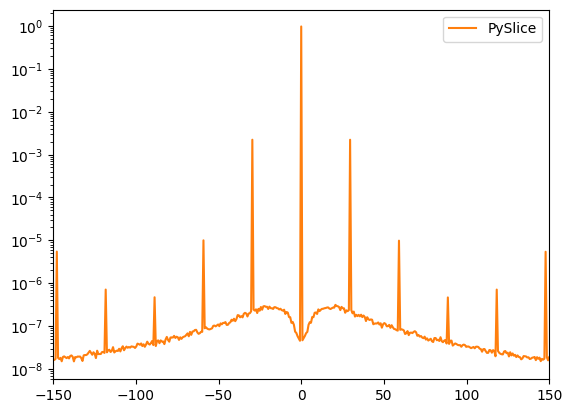

In [4]:
fig, ax = plt.subplots()

thetax = np.fft.fftshift(wf.probe.kxs) * wavelength * 1e3
thetay = np.fft.fftshift(wf.probe.kys) * wavelength * 1e3
mask1 = np.floor(np.abs(thetax)) <= 150
mask2 = np.floor(np.abs(thetay)) <= 5

thetax = thetax[mask1]
intensity = (np.abs(wavs_pyslice[0,...,0])**2).mean(axis=(0,))

ax.semilogy(thetax, intensity[np.ix_(mask1, mask2)].sum(axis=-1), color='tab:orange', label='PySlice')

ax.set_xlim(left=-150, right=150)
ax.legend()

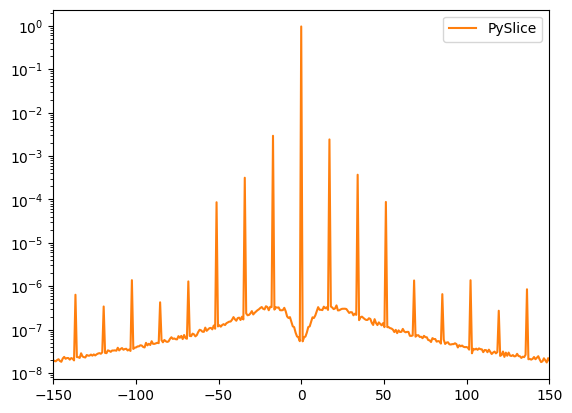

In [5]:
fig, ax = plt.subplots()

thetax = np.fft.fftshift(wf.probe.kxs) * wavelength * 1e3
thetay = np.fft.fftshift(wf.probe.kys) * wavelength * 1e3
mask1 = np.floor(np.abs(thetax)) <= 5
mask2 = np.floor(np.abs(thetay)) <= 150

thetay = thetay[mask2]
intensity = (np.abs(wavs_pyslice[0,...,0])**2).mean(axis=(0,))

ax.semilogy(thetay, intensity[np.ix_(mask1, mask2)].sum(axis=0), color='tab:orange', label='PySlice')

ax.set_xlim(left=-150, right=150)
ax.legend()

In [6]:
from pyslice import backend
backend.sum(backend.absolute(wf.array)**2, axis=(0,2,3,4))

array([7.56378678e+11, 7.56378675e+11, 7.56378726e+11, 7.56378677e+11,
       7.56378682e+11, 7.56378677e+11, 7.56378701e+11, 7.56378715e+11,
       7.56378734e+11, 7.56378688e+11])

# *ab*TEM

In [7]:
atoms_test = [trajectory.select_timesteps((i,)).to_ase() for i in range(trajectory.n_frames)]
atoms_test

[Atoms(symbols='B2000N2000', pbc=True, cell=[50.08, 43.37055222152468, 16.96]),
 Atoms(symbols='B2000N2000', pbc=True, cell=[50.08, 43.37055222152468, 16.96]),
 Atoms(symbols='B2000N2000', pbc=True, cell=[50.08, 43.37055222152468, 16.96]),
 Atoms(symbols='B2000N2000', pbc=True, cell=[50.08, 43.37055222152468, 16.96]),
 Atoms(symbols='B2000N2000', pbc=True, cell=[50.08, 43.37055222152468, 16.96]),
 Atoms(symbols='B2000N2000', pbc=True, cell=[50.08, 43.37055222152468, 16.96]),
 Atoms(symbols='B2000N2000', pbc=True, cell=[50.08, 43.37055222152468, 16.96]),
 Atoms(symbols='B2000N2000', pbc=True, cell=[50.08, 43.37055222152468, 16.96]),
 Atoms(symbols='B2000N2000', pbc=True, cell=[50.08, 43.37055222152468, 16.96]),
 Atoms(symbols='B2000N2000', pbc=True, cell=[50.08, 43.37055222152468, 16.96])]

In [8]:
import abtem
from abtem.array import ComputableList

energy = 100e3
sampling = 0.5
sampling_scan = None
SEMIANGLE_CUTOFF = 0.001
MAX_ANGLE = 150.0

abtem.config.set({"device":      "cpu",
                  "precision":   "float64"});

ensemble = abtem.AtomsEnsemble(atoms_test, ensemble_mean=False)

potential = abtem.Potential(
    ensemble,
#    atoms_test[0],
    slice_thickness = 0.5,
    sampling = 0.05,
#        gpts = config['discretization']['gpts'],
)

probe = abtem.Probe(energy=energy, semiangle_cutoff=SEMIANGLE_CUTOFF)
probe.match_grid(potential)

scan = abtem.GridScan(
    (0, 0), end=(1 / reps[0], 1 / reps[1]), fractional=True, potential=potential,
    sampling=sampling_scan,
)

detectors = [
    abtem.detectors.WavesDetector(to_cpu=False),
    abtem.AnnularDetector(inner=80, outer=200),
]

exit_waves, haadf_images = probe.scan(
    potential=potential, scan=scan, detectors=detectors,
)

measurements = ComputableList(
    [
        exit_waves.diffraction_patterns(max_angle=MAX_ANGLE, return_complex=True),
        haadf_images
    ]
)

# We compute here to get everything into memory and avoid a second computation later
measurements.compute()

potential_abtem = potential.build()
wavs_abtem = measurements[0].to_data_array().to_numpy()

tasks:   0%|          | 0/52 [00:00<?, ?it/s]

(-50.0, 50.0)

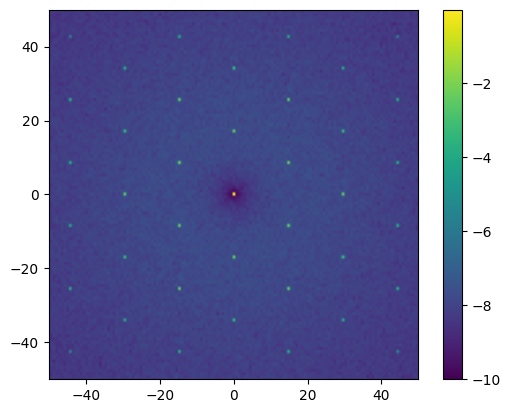

In [9]:
fig, ax = plt.subplots()

extent = (
    measurements[0].angular_limits[0][0], 
    measurements[0].angular_limits[0][-1],
    measurements[0].angular_limits[1][0],
    measurements[0].angular_limits[1][-1],
)

intensity = np.mean(np.abs(wavs_abtem)**2, axis=0)[0,0,...]

im = ax.imshow(np.log10(intensity.T+1e-40), vmin=-10, extent=extent, origin='lower')

fig.colorbar(im, ax=ax)

ax.set_xlim(left=-50, right=50)
ax.set_ylim(bottom=-50, top=50)

(407, 5)
(409, 5)


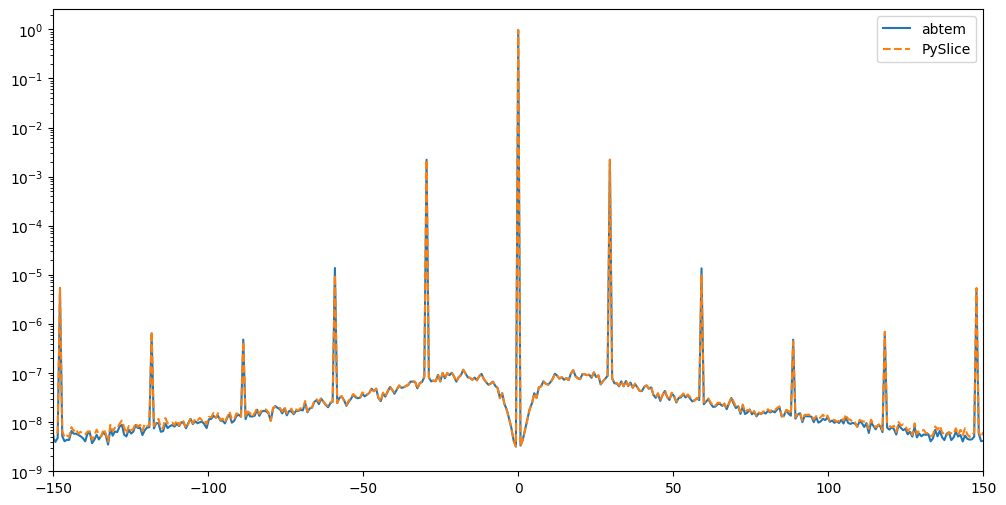

In [10]:
fig, ax = plt.subplots(figsize=(12,6))

thetax = measurements[0].angular_coordinates[0]
thetay = measurements[0].angular_coordinates[1]
mask1 = np.floor(np.abs(thetax)) <= 150
mask2 = np.floor(np.abs(thetay)) <= 1
#print(thetax)
intensity = np.mean(np.abs(wavs_abtem)**2, axis=0)[0,0,...]

print(intensity[np.ix_(mask1, mask2)].shape)
ax.semilogy(thetax, intensity[np.ix_(mask1, mask2)].sum(axis=-1), label='abtem')

thetax = fftshift(wf.probe.kxs) * wf.probe.wavelength * 1e3
thetay = fftshift(wf.probe.kys) * wf.probe.wavelength * 1e3
mask1 = np.floor(np.abs(thetax)) <= 150
mask2 = np.floor(np.abs(thetay)) <= 1
thetax = thetax[mask1]
#print(thetax)
intensity = (np.abs(wavs_pyslice[0,...,0])**2).mean(axis=0)

print(intensity[np.ix_(mask1, mask2)].shape)

ax.semilogy(thetax, intensity[np.ix_(mask1, mask2)].sum(axis=-1), label='PySlice', ls='--')

ax.set_xlim(left=-150, right=150)
ax.set_ylim(bottom=1e-9)
ax.legend()

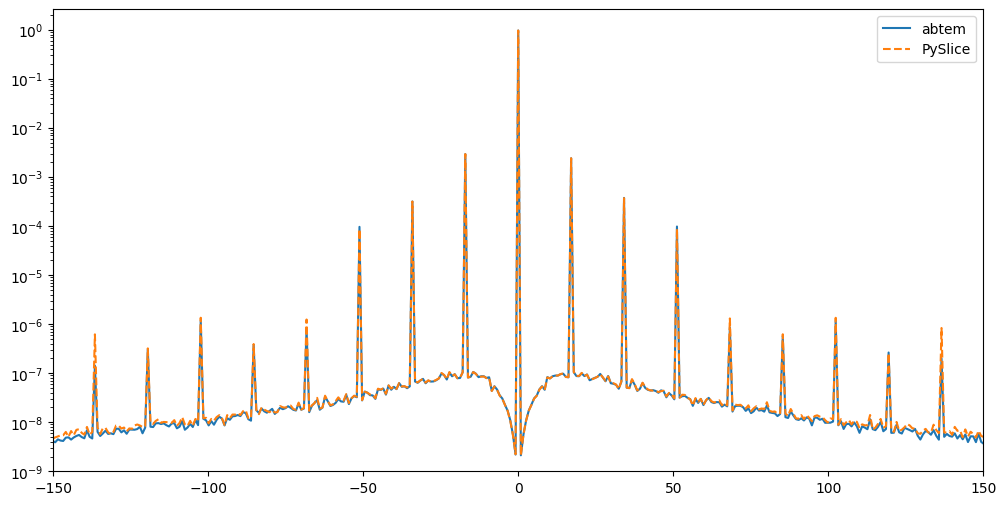

In [11]:
fig, ax = plt.subplots(figsize=(12,6))

thetax = measurements[0].angular_coordinates[0]
thetay = measurements[0].angular_coordinates[1]
mask1 = np.floor(np.abs(thetax)) <= 1
mask2 = np.floor(np.abs(thetay)) <= 150

intensity = np.mean(np.abs(wavs_abtem)**2, axis=0)[0,0,...]

ax.semilogy(thetay, intensity[np.ix_(mask1, mask2)].sum(axis=0), label='abtem')

thetax = fftshift(wf.probe.kxs) * wf.probe.wavelength * 1e3
thetay = fftshift(wf.probe.kys) * wf.probe.wavelength * 1e3
mask1 = np.floor(np.abs(thetax)) <= 1
mask2 = np.floor(np.abs(thetay)) <= 150

thetay = thetay[mask2]
intensity = (np.abs(wavs_pyslice[0,...,0])**2).mean(axis=0)

ax.semilogy(thetay, intensity[np.ix_(mask1, mask2)].sum(axis=0), label='PySlice', ls='--')

ax.set_xlim(left=-150, right=150)
ax.set_ylim(bottom=1e-9)
ax.legend()

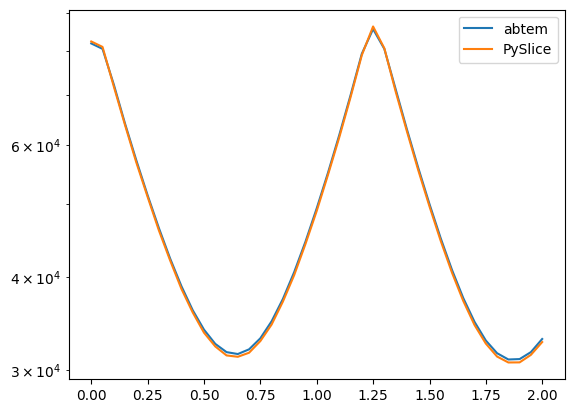

In [12]:
fig, ax = plt.subplots()

xs = np.array(potential_abtem.axes_metadata[2].coordinates(potential_abtem.shape[2]))
ys = np.array(potential_abtem.axes_metadata[3].coordinates(potential_abtem.shape[3]))

mask1 = np.floor(np.abs(xs)) <= 1
mask2 = np.floor(np.abs(ys)) <= 10
xs = xs[mask1]

intensity = np.abs(potential_abtem.to_data_array().to_numpy()[0,...]).sum(axis=0)
ax.semilogy(xs, intensity[np.ix_(mask1, mask2)].sum(axis=1), label='abtem')


xs = np.array(list(potential_pyslice.xs))
ys = np.array(list(potential_pyslice.ys))

mask1 = np.floor(np.abs(xs)) <= 1
mask2 = np.floor(np.abs(ys)) <= 10
xs = xs[mask1]

intensity = potential_pyslice.array.sum(axis=(-1,))

ax.semilogy(xs, intensity[np.ix_(mask1, mask2)].sum(axis=1), color='tab:orange', label='PySlice')

#ax.set_xlim(left=-150, right=150)
ax.legend()

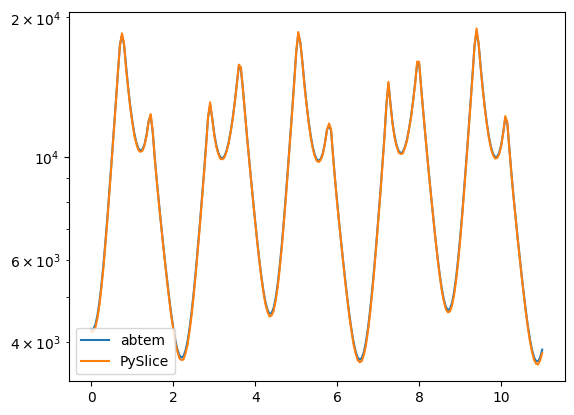

In [14]:
fig, ax = plt.subplots()

xs = np.array(potential_abtem.axes_metadata[2].coordinates(potential_abtem.shape[2]))
ys = np.array(potential_abtem.axes_metadata[3].coordinates(potential_abtem.shape[3]))

mask1 = np.floor(np.abs(xs)) <= 1
mask2 = np.floor(np.abs(ys)) <= 10
ys = ys[mask2]

intensity = np.abs(potential_abtem.to_data_array().to_numpy()[0,...]).sum(axis=0)
ax.semilogy(ys, intensity[np.ix_(mask1, mask2)].sum(axis=0), label='abtem')


xs = np.array(list(potential_pyslice.xs))
ys = np.array(list(potential_pyslice.ys))

mask1 = np.floor(np.abs(xs)) <= 1
mask2 = np.floor(np.abs(ys)) <= 10
ys = ys[mask2]

intensity = potential_pyslice.array.sum(axis=(-1,))

ax.semilogy(ys, intensity[np.ix_(mask1, mask2)].sum(axis=0), color='tab:orange', label='PySlice')

ax.legend()